# Regression for Large Matrices with Joint Column and Row Reduction - Visualizations
Loss, total time, and screening plots for all CUR reduction pipelines.

In [0]:
import sys
import os
import pickle
import numpy as np

sys.path.append(os.path.dirname(os.path.abspath("__file__")))

from evaluation import evaluate_experiment
from visualizations import (
    plot_loss_boxplots,
    plot_screening_boxplots,
    plot_score_distributions,
    plot_n_selected,
)

In [0]:
# === Paths ===
BASE = "/Users/timschmale/Documents/GIT/Masterthesis/"
DATA_FOLDER = "Simulation Data/p5000_n5000"
RESULTS_FOLDER = "Results/p5000"
SAVE_PATH = os.path.join(BASE, "Plots/p5000")  # PDF output

# === Parameters ===
k_vector = [10, 20, 25, 50, 100, 200, 300, 400, 500]
REPS = 10
OUTER_REPS = 10
DATASET = "p5000"

In [0]:
def load_all_seeds(base, results_folder, save_name, seed_from=1, seed_to=11):
    """Load per-seed pickles and merge into one results dict."""
    all_results = {}
    path = os.path.join(base, results_folder)
    for seed in range(seed_from, seed_to):
        fpath = os.path.join(path, f"{save_name}_seed_{seed}.pkl")
        if os.path.exists(fpath):
            with open(fpath, "rb") as f:
                all_results[seed] = pickle.load(f)
        else:
            print(f"  [WARN] Missing: {fpath}")
    print(f"Loaded {len(all_results)} seeds for '{save_name}'.")
    return all_results

# Load all pipeline results
results_ols_col_row = load_all_seeds(BASE, RESULTS_FOLDER, "results_ols_col_row")
results_ols_col_only = load_all_seeds(BASE, RESULTS_FOLDER, "results_ols_col_only")
results_ols_row_col = load_all_seeds(BASE, RESULTS_FOLDER, "results_ols_row_col")
results_logistic = load_all_seeds(BASE, RESULTS_FOLDER, "results_logistic")
results_lasso = load_all_seeds(BASE, RESULTS_FOLDER, "results_lasso")

## Loss & Total Time

In [0]:
plot_loss_boxplots(results_ols_col_row, k_vector, metric="rmse_test",
                   pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_row, k_vector, metric="rmse_train",
                   pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_row, k_vector, metric="time_total",
                   pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

In [0]:
plot_loss_boxplots(results_ols_col_only, k_vector, metric="rmse_test",
                   pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_only, k_vector, metric="rmse_train",
                   pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_only, k_vector, metric="time_total",
                   pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

In [0]:
plot_loss_boxplots(results_ols_row_col, k_vector, metric="rmse_test",
                   pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_row_col, k_vector, metric="rmse_train",
                   pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_row_col, k_vector, metric="time_total",
                   pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

In [0]:
plot_loss_boxplots(results_logistic, k_vector, metric="brier_test",
                   pipeline="logistic", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_logistic, k_vector, metric="ce_test",
                   pipeline="logistic", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_logistic, k_vector, metric="time_total",
                   pipeline="logistic", dataset=DATASET, save_path=SAVE_PATH)

In [0]:
plot_loss_boxplots(results_lasso, k_vector, metric="rmse_test",
                   pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_lasso, k_vector, metric="rmse_train",
                   pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_lasso, k_vector, metric="time_total",
                   pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

## Screening (TPR, FDR, MCC)

In [0]:
# OLS Pipelines
screening_col_row = evaluate_experiment(results_ols_col_row, BASE, DATA_FOLDER, REPS)
screening_col_only = evaluate_experiment(results_ols_col_only, BASE, DATA_FOLDER, REPS)
screening_row_col = evaluate_experiment(results_ols_row_col, BASE, DATA_FOLDER, REPS)

# Logistic
screening_logistic = evaluate_experiment(results_logistic, BASE, DATA_FOLDER, REPS)

# Lasso
screening_lasso = evaluate_experiment(results_lasso, BASE, DATA_FOLDER, REPS)

print("Screening evaluation done.")
print(f"  col_row:  {len(screening_col_row)} rows")
print(f"  col_only: {len(screening_col_only)} rows")
print(f"  row_col:  {len(screening_row_col)} rows")
print(f"  logistic: {len(screening_logistic)} rows")
print(f"  lasso:    {len(screening_lasso)} rows")

In [0]:
plot_screening_boxplots(screening_col_row, pipeline="col_row", dataset=DATASET,
                        save_path=SAVE_PATH)

In [0]:
plot_screening_boxplots(screening_col_only, pipeline="col_only", dataset=DATASET,
                        save_path=SAVE_PATH)

In [0]:
plot_screening_boxplots(screening_row_col, pipeline="row_col", dataset=DATASET,
                        save_path=SAVE_PATH)

In [0]:
plot_screening_boxplots(screening_logistic, pipeline="logistic", dataset=DATASET,
                        save_path=SAVE_PATH)

In [0]:
plot_screening_boxplots(screening_lasso, pipeline="lasso", dataset=DATASET,
                        save_path=SAVE_PATH)

## Score Distributions & Number of Selected Features

In [42]:
import pandas as pd
from scoring import compute_all_scores

# Load first replication
DATA_PATH = os.path.join(BASE, DATA_FOLDER)
X_rep = pd.read_csv(os.path.join(DATA_PATH, "X1.csv")).to_numpy()
y_rep = pd.read_csv(os.path.join(DATA_PATH, "y1.csv")).to_numpy().ravel()
y_bin = pd.read_csv(os.path.join(DATA_PATH, "y_binary1.csv")).to_numpy().ravel()

# Compute scores for k=100 (representative)
k_score = 100

# Continuous response (OLS + Lasso pipelines)
scores_cont, _ = compute_all_scores(X_rep, y_rep, k_score)
scores_single_cont = {
    "CLS": scores_cont["CLS"],
    "CS":  scores_cont["CS"],
    "LS":  scores_cont["LS"],
    "RS":  scores_cont["RS"]
}

# Binary response (Logistic pipeline)
scores_bin, _ = compute_all_scores(X_rep, y_bin, k_score)
scores_single_bin = {
    "CLS": scores_bin["CLS"],
    "CS":  scores_bin["CS"],
    "LS":  scores_bin["LS"],
    "RS":  scores_bin["RS"]
}

print(f"Scores computed for k={k_score} (continuous + binary).")

Scores computed for k=100 (continuous + binary).


/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_col_row_scores_p5000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_col_row_scores_p5000.pdf


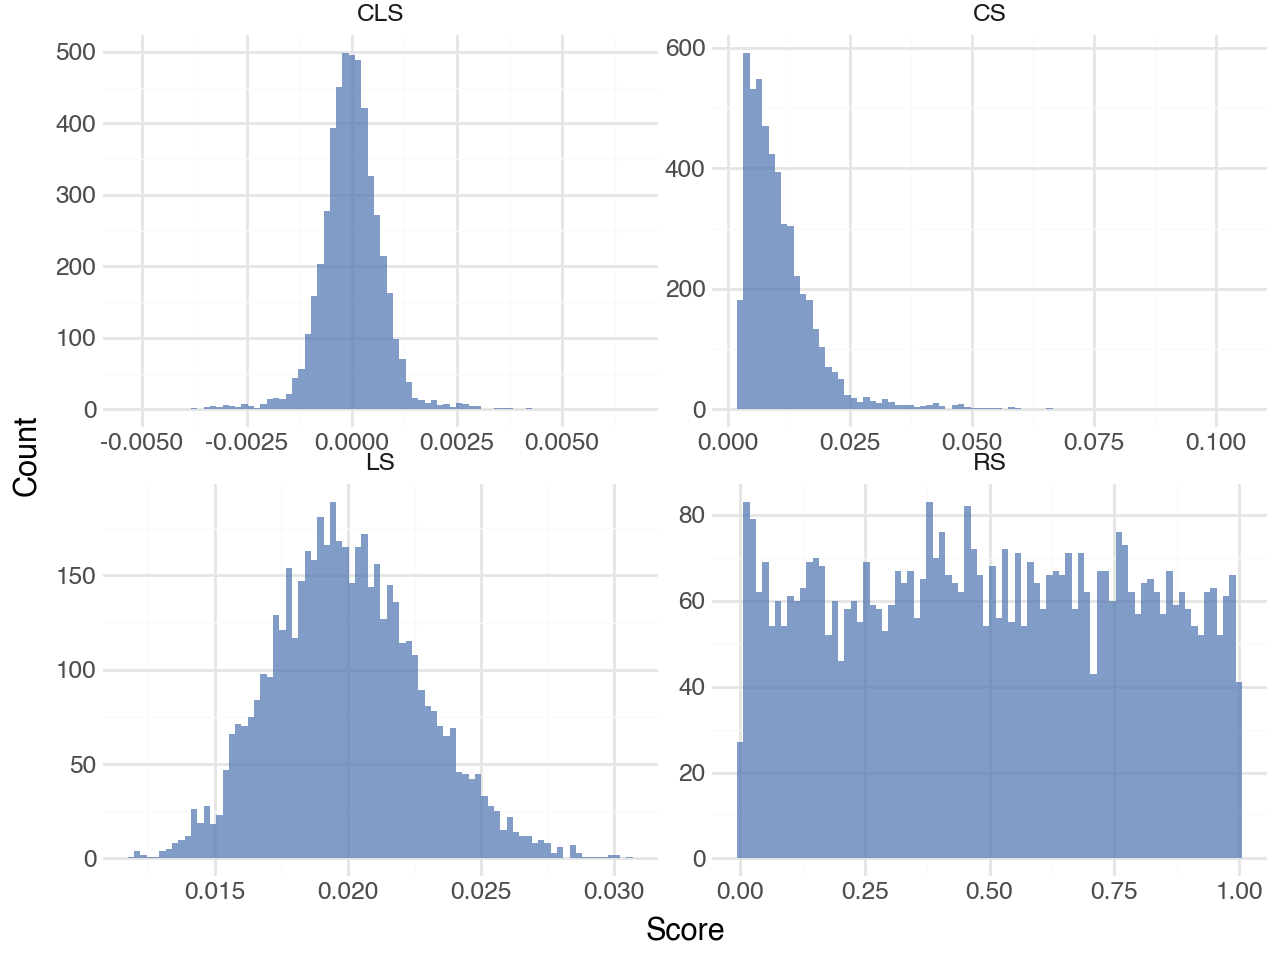

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_col_only_scores_p5000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_col_only_scores_p5000.pdf


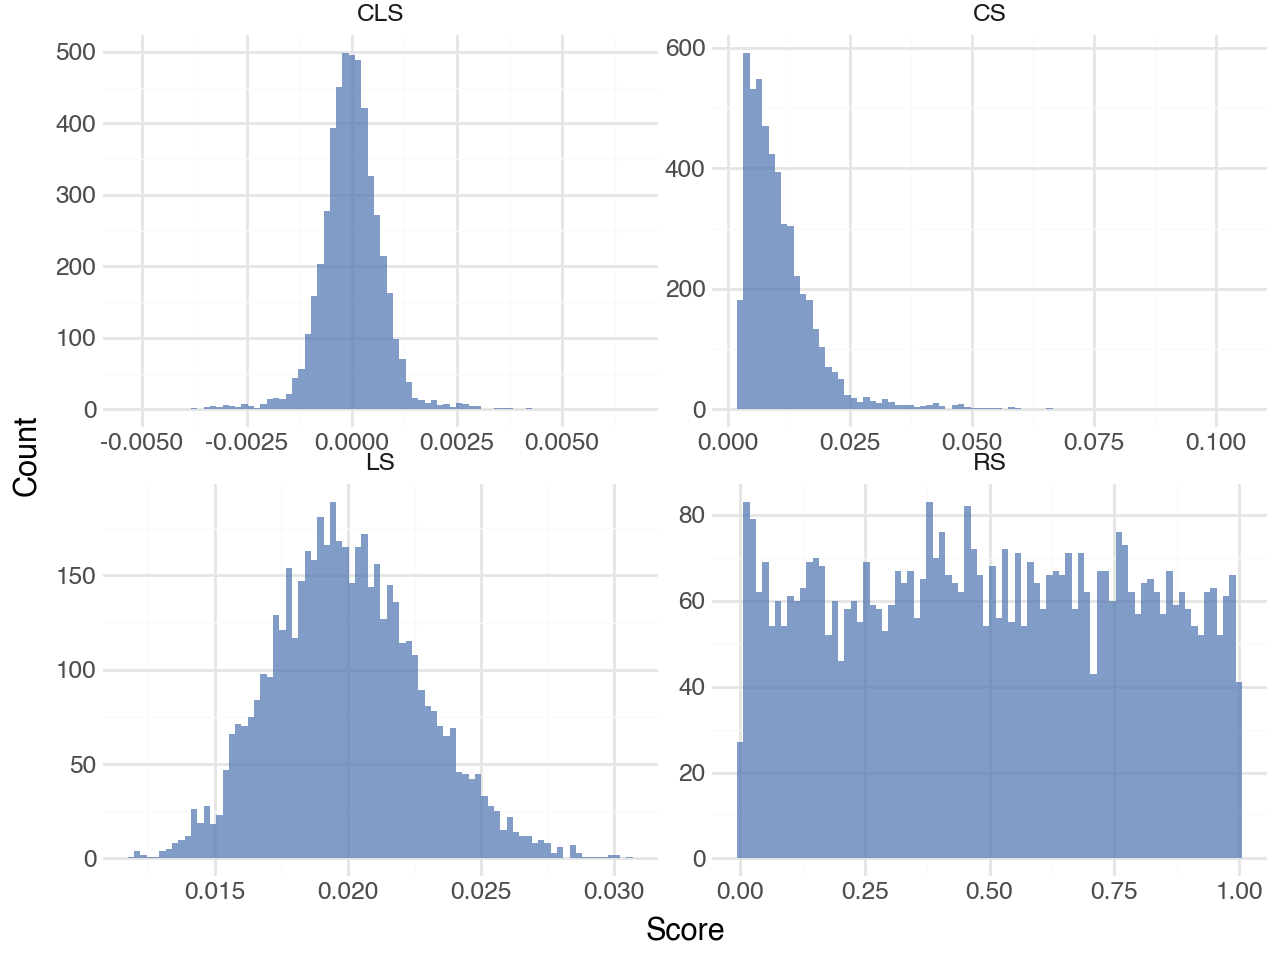

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_row_col_scores_p5000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_row_col_scores_p5000.pdf


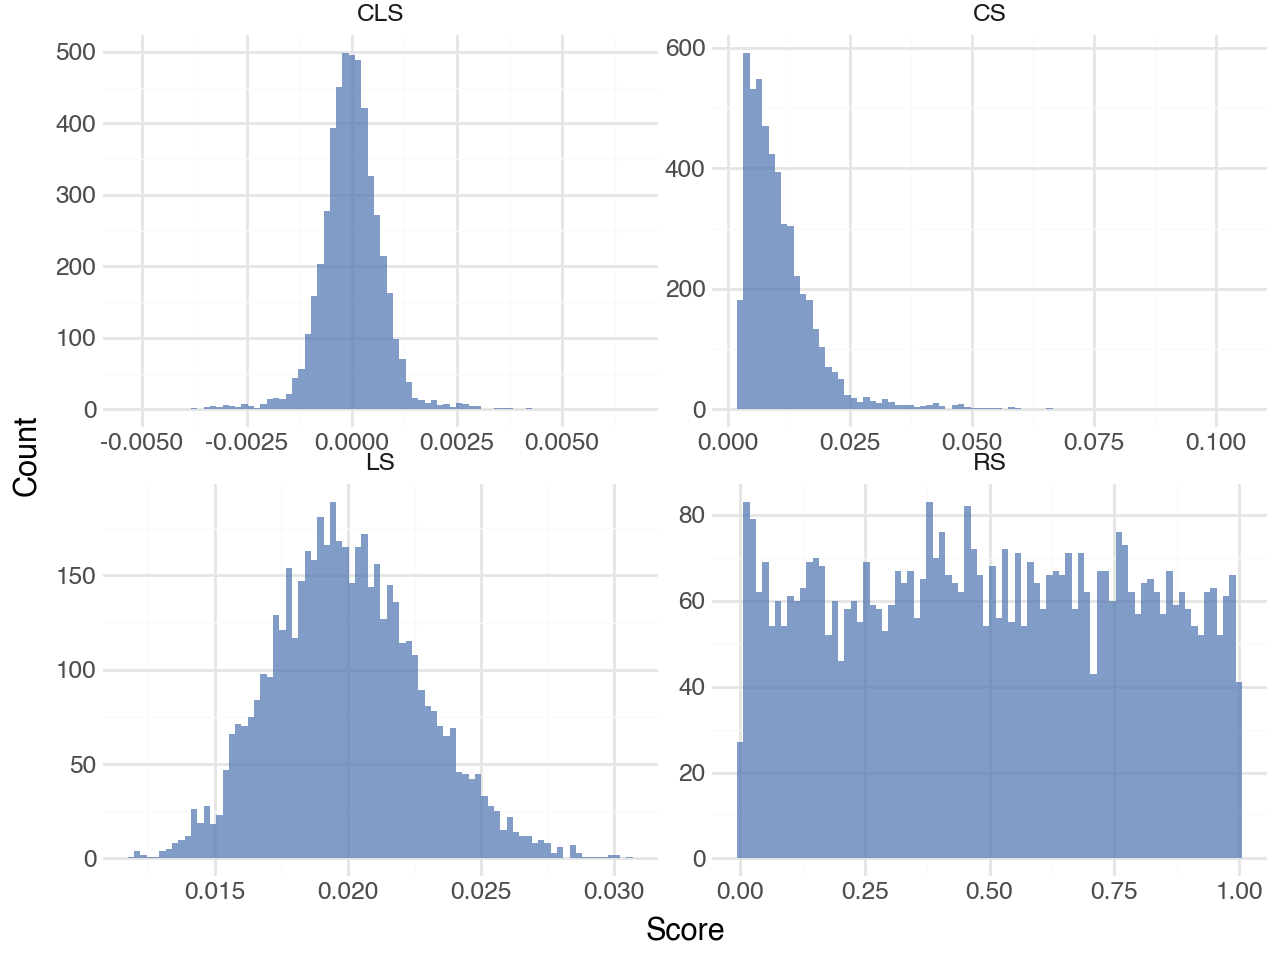

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_logistic_scores_p5000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_logistic_scores_p5000.pdf


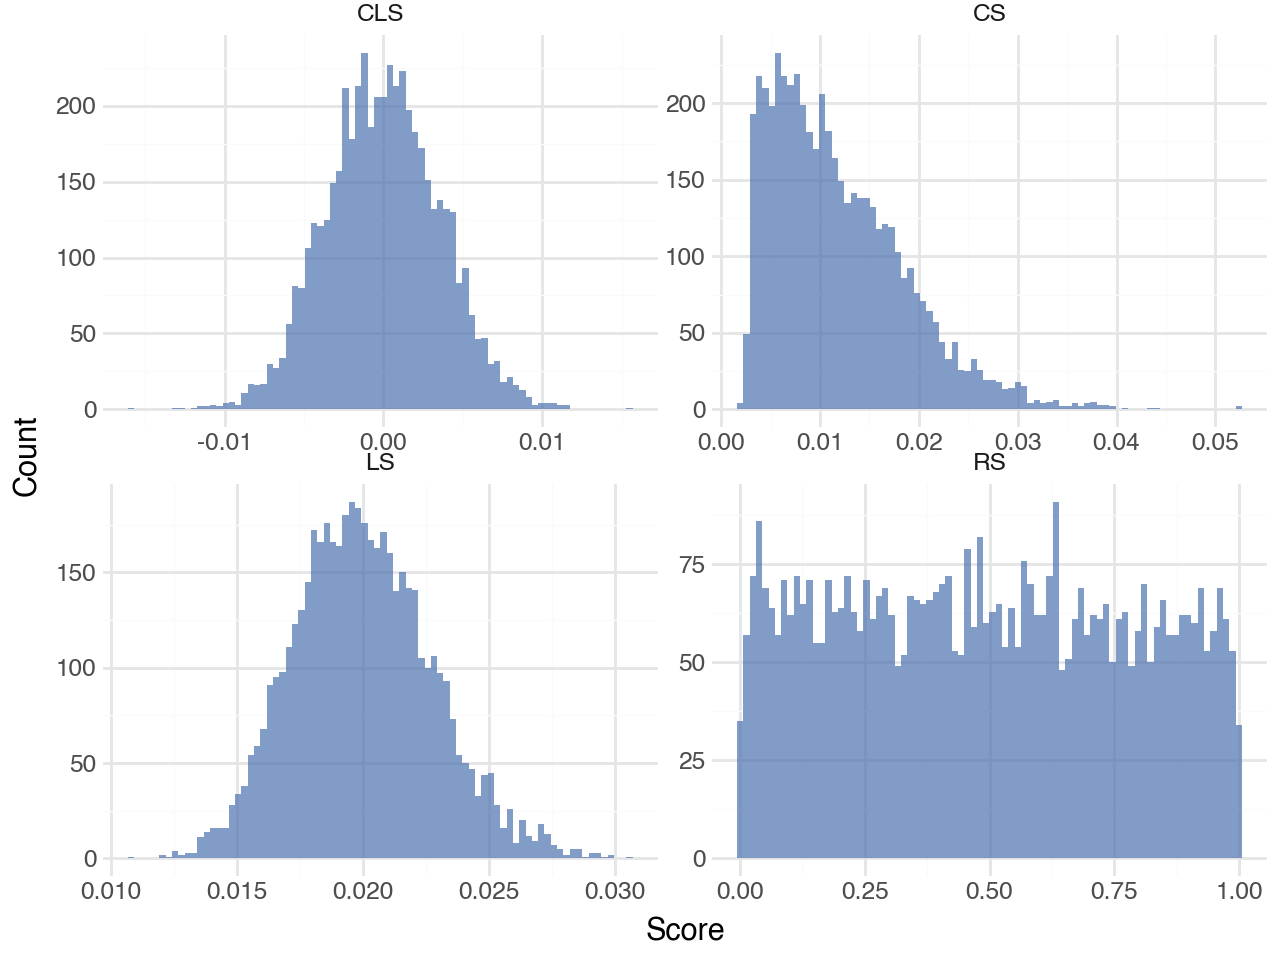

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_lasso_scores_p5000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p5000/results_lasso_scores_p5000.pdf


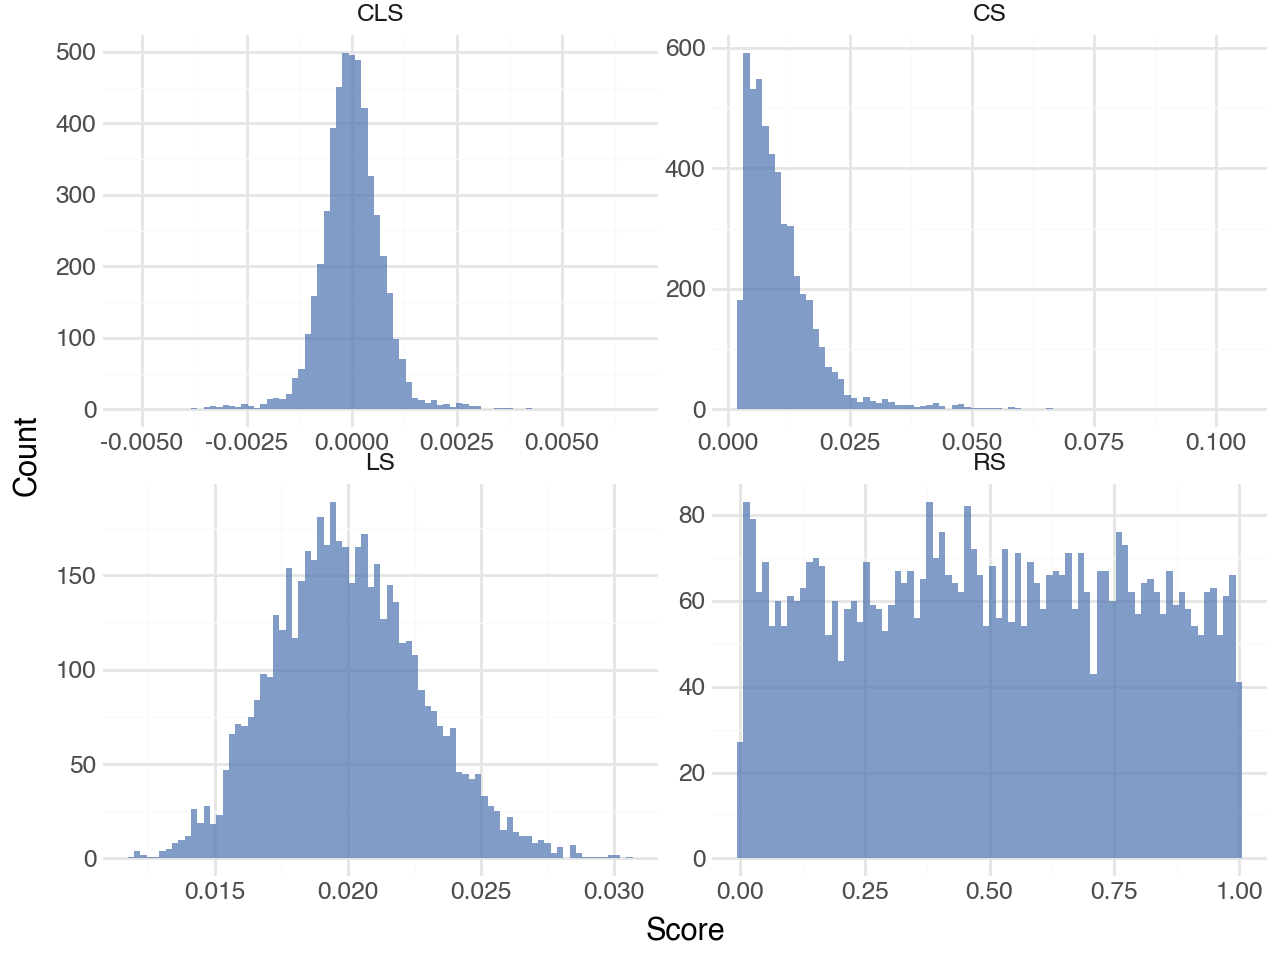

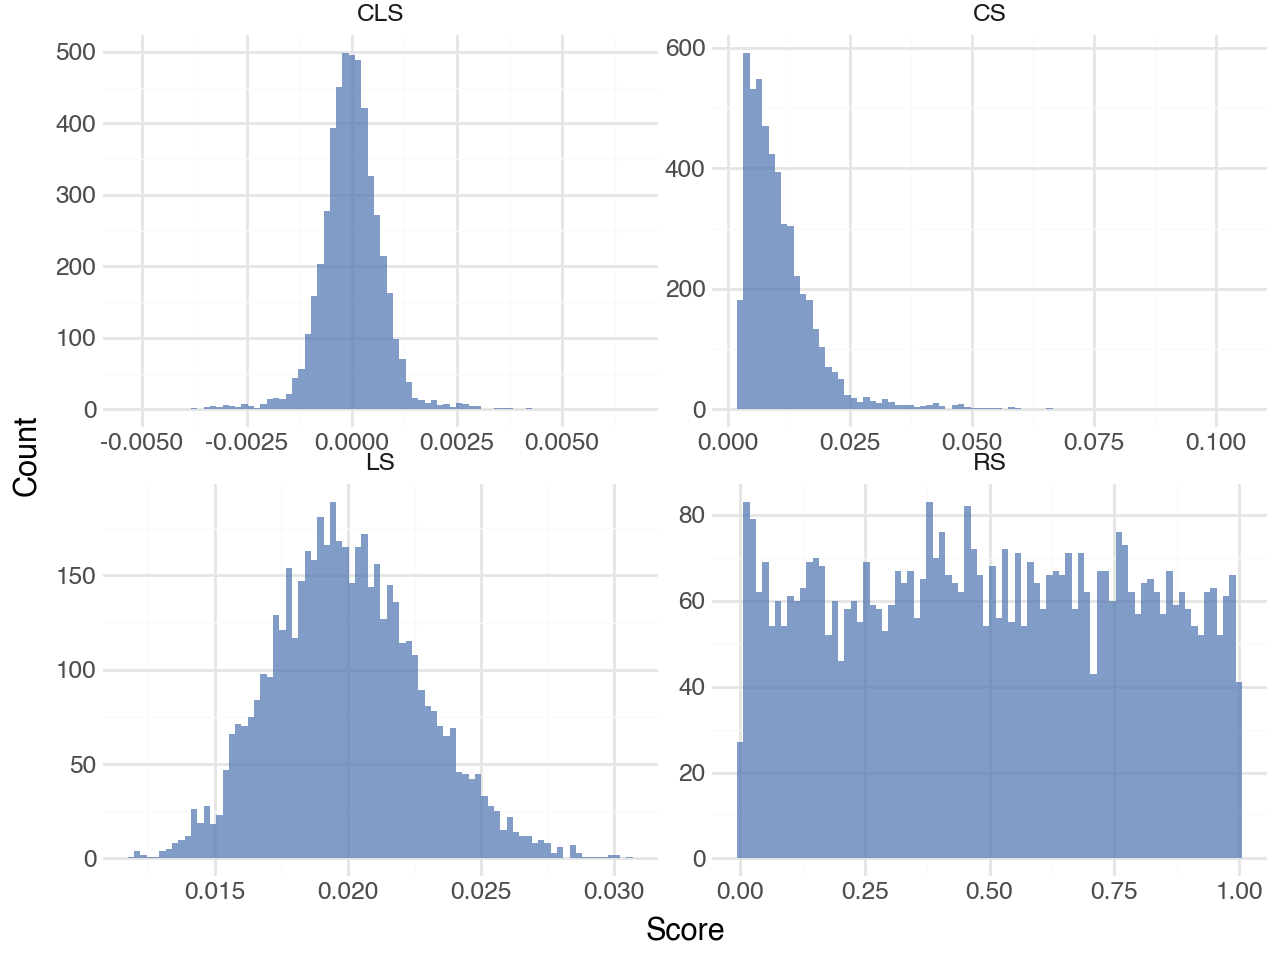

In [43]:
# OLS Pipelines (continuous response)
plot_score_distributions(scores_single_cont, pipeline="col_row",
                        dataset=DATASET, save_path=SAVE_PATH)

plot_score_distributions(scores_single_cont, pipeline="col_only",
                        dataset=DATASET, save_path=SAVE_PATH)

plot_score_distributions(scores_single_cont, pipeline="row_col",
                        dataset=DATASET, save_path=SAVE_PATH)

# Logistic (binary response)
plot_score_distributions(scores_single_bin, pipeline="logistic",
                        dataset=DATASET, save_path=SAVE_PATH)

# Lasso (continuous response)
plot_score_distributions(scores_single_cont, pipeline="lasso",
                        dataset=DATASET, save_path=SAVE_PATH)